<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Lab%208/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [4]:
df

,Unnamed: 0,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,1,1,37,11,1,0,1,1,0.0,0.0,9930.0460
1,2,1,22,9,0,1,0,1,0.0,0.0,3595.8940
2,3,1,30,12,1,0,0,0,0.0,0.0,24909.4500
3,4,1,27,11,1,0,0,1,0.0,0.0,7506.1460
4,5,1,33,8,1,0,0,1,0.0,0.0,289.7899
...,...,...,...,...,...,...,...,...,...,...,...
609,610,0,18,11,0,0,0,1,0.0,0.0,10150.5000
610,611,0,24,1,0,1,1,1,0.0,0.0,19464.6100
611,612,0,21,18,0,0,0,0,0.0,0.0,0.0000
612,613,0,32,5,1,0,1,1,0.0,0.0,187.6713


In [5]:
df = pd.read_csv('lalonde.csv')

treated = df[df['treat'] == 1]['re78']
control = df[df['treat'] == 0]['re78']

print(f"Mean Treated: ${treated.mean():.2f}")
print(f"Mean Control: ${control.mean():.2f}")

Mean Treated: $6349.14
Mean Control: $6984.17


In [6]:
signal = treated.mean() - control.mean()

t_stat, p_val = stats.ttest_ind(treated, control, equal_var=False)

print(f"Treatment Effect (Signal): ${signal:.2f}")
print(f"T-Statistic (Signal/Noise): {signal:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val<0.05:
  print("Reject null: The training has a statistically significant effect.")
else:
  print("Fail to Reject the null: Result could be due to change.")

Treatment Effect (Signal): $-635.03
T-Statistic (Signal/Noise): -635.0262
P-Value: 0.3491
Fail to Reject the null: Result could be due to change.


In [11]:
def difference_in_means(x, y):
  return np.mean(x) - np.mean(y)

res = stats.permutation_test((treated, control), difference_in_means,
                               permutation_type='independent',
                               n_resamples=10000,
                               alternative='two-sided')

print(f"Permutation P-value: {res.pvalue:.4f}")
print("compare this to your T-test P-value. Are they consistent?")

Permutation P-value: 0.3290
compare this to your T-test P-value. Are they consistent?


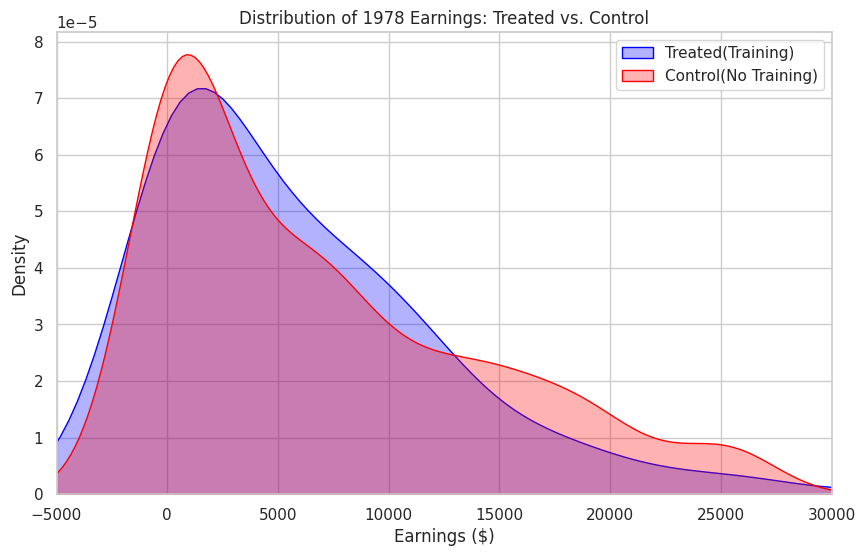

In [12]:
plt.figure(figsize=(10,6))

sns.kdeplot(treated, fill=True, label='Treated(Training)', color='blue', alpha=0.3)
sns.kdeplot(control, fill=True, label='Control(No Training)', color='red', alpha=0.3)

plt.title('Distribution of 1978 Earnings: Treated vs. Control')
plt.xlabel('Earnings ($)')
plt.xlim(-5000, 30000)
plt.legend()
plt.show()